# Credit Scoring Model for Loan Approval Decisions

**Dataset:** German Credit (Statlog), 1000 tətbiqçi (700 good / 300 bad)
**Məqsəd:** Tətbiqçinin application-time məlumatlarına əsasən default ehtimalını proqnozlaşdırmaq və bunu cost-əsaslı approve/decline qərarına çevirmək.

**Əsas addımlar:** Data hazırlığı → Baseline (Logistic Regression) və XGBoost modelləri → Cost-aware threshold seçimi → SHAP izahatı → Bonus: Scorecard, Fairness analizi.

**Yekun qərar:** Logistic Regression, threshold=0.46 (cost-optimal, cost matrix: FN=5, FP=1 əsasında).

In [1]:
import pandas as pd

columns = [
    "checking_status", "duration_months", "credit_history", "purpose",
    "credit_amount", "savings_status", "employment_since", "installment_rate_pct",
    "personal_status_sex", "other_debtors", "residence_since", "property",
    "age", "other_installment_plans", "housing", "existing_credits",
    "job", "num_dependents", "telephone", "foreign_worker", "target"
]

df = pd.read_csv("german.data", sep=" ", header=None, names=columns)

# target: 1 = good, 2 = bad -> çeviririk: 1 = bad (default), 0 = good
df["target"] = df["target"].map({1: 0, 2: 1})  # 1 = bad credit (bizim "pozitiv" sinif)

print(df.shape)
df.head()

(1000, 21)


,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


##  Datasetin yüklənməsi

German Credit (Statlog) dataseti `german.data` faylından yükləndi. Fayl boşluqla ayrılmış, başlıqsız formatdadır, ona görə sütun adları `german.doc` sənədindəki 20 atribut təsvirinə əsasən əl ilə təyin edildi. 21-ci sütun (`target`) 1=good, 2=bad kimi kodlanıb; biz onu standart konvensiyaya uyğun olaraq 0=good, 1=bad şəklinə çevirdik ki, "1" həmişə minority/riskli sinifi (default) ifadə etsin.

In [2]:
# german.doc-a əsasən kod -> mənalı ad mapping-ləri

checking_status_map = {
    "A11": "< 0 DM", "A12": "0-200 DM", "A13": ">= 200 DM", "A14": "no checking account"
}
credit_history_map = {
    "A30": "no credits/all paid", "A31": "all paid (this bank)",
    "A32": "existing credits paid duly", "A33": "delay in past",
    "A34": "critical account/other credits"
}
purpose_map = {
    "A40": "car (new)", "A41": "car (used)", "A42": "furniture/equipment",
    "A43": "radio/tv", "A44": "domestic appliances", "A45": "repairs",
    "A46": "education", "A47": "vacation", "A48": "retraining",
    "A49": "business", "A410": "other"
}
savings_status_map = {
    "A61": "< 100 DM", "A62": "100-500 DM", "A63": "500-1000 DM",
    "A64": ">= 1000 DM", "A65": "unknown/no savings"
}
employment_since_map = {
    "A71": "unemployed", "A72": "< 1 year", "A73": "1-4 years",
    "A74": "4-7 years", "A75": ">= 7 years"
}
personal_status_sex_map = {
    "A91": "male: divorced/separated", "A92": "female: div/sep/married",
    "A93": "male: single", "A94": "male: married/widowed", "A95": "female: single"
}
other_debtors_map = {
    "A101": "none", "A102": "co-applicant", "A103": "guarantor"
}
property_map = {
    "A121": "real estate", "A122": "building society/life insurance",
    "A123": "car/other", "A124": "unknown/no property"
}
other_installment_plans_map = {
    "A141": "bank", "A142": "stores", "A143": "none"
}
housing_map = {
    "A151": "rent", "A152": "own", "A153": "for free"
}
job_map = {
    "A171": "unemployed/unskilled non-resident", "A172": "unskilled resident",
    "A173": "skilled employee", "A174": "management/self-employed/highly qualified"
}
telephone_map = {
    "A191": "none", "A192": "yes"
}
foreign_worker_map = {
    "A201": "yes", "A202": "no"
}

mapping_dict = {
    "checking_status": checking_status_map,
    "credit_history": credit_history_map,
    "purpose": purpose_map,
    "savings_status": savings_status_map,
    "employment_since": employment_since_map,
    "personal_status_sex": personal_status_sex_map,
    "other_debtors": other_debtors_map,
    "property": property_map,
    "other_installment_plans": other_installment_plans_map,
    "housing": housing_map,
    "job": job_map,
    "telephone": telephone_map,
    "foreign_worker": foreign_worker_map,
}

df_readable = df.copy()
for col, mapping in mapping_dict.items():
    df_readable[col] = df_readable[col].map(mapping)

df_readable.head()

,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,< 0 DM,6,critical account/other credits,radio/tv,1169,unknown/no savings,>= 7 years,4,male: single,none,...,real estate,67,none,own,2,skilled employee,1,yes,yes,0
1,0-200 DM,48,existing credits paid duly,radio/tv,5951,< 100 DM,1-4 years,2,female: div/sep/married,none,...,real estate,22,none,own,1,skilled employee,1,none,yes,1
2,no checking account,12,critical account/other credits,education,2096,< 100 DM,4-7 years,2,male: single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,< 0 DM,42,existing credits paid duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male: single,guarantor,...,building society/life insurance,45,none,for free,1,skilled employee,2,none,yes,0
4,< 0 DM,24,delay in past,car (new),4870,< 100 DM,1-4 years,3,male: single,none,...,unknown/no property,53,none,for free,2,skilled employee,2,none,yes,1


##  Kateqorik kodların oxunaqlı adlara çevrilməsi

Dataset kateqorik atributları `A11`, `A34` kimi kodlarla ifadə edir. Bu kodlar `german.doc`-dakı rəsmi izahata əsasən mənalı yazılara (məsələn `A11` → "< 0 DM") çevrildi. Bu addım, sonrakı SHAP izahatlarının insan tərəfindən oxuna bilən olması üçün vacibdir — modelin "checking_status = A11" yox, "checking_status = < 0 DM" görməsi qərarların şərh olunmasını asanlaşdırır.

target
0    700
1    300
Name: count, dtype: int64
target
0    0.7
1    0.3
Name: proportion, dtype: float64


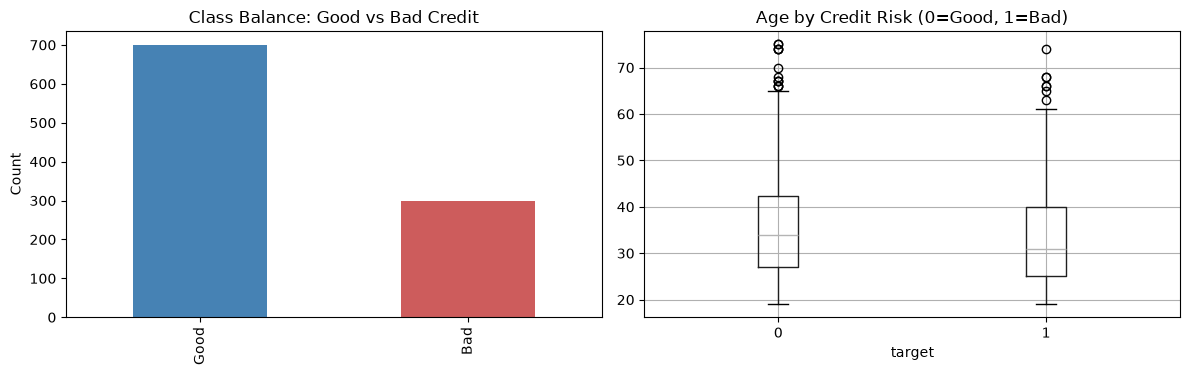

In [3]:
import matplotlib.pyplot as plt

# Sinif balansını yoxlayaq
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sinif balansı
df["target"].map({0: "Good", 1: "Bad"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["steelblue", "indianred"]
)
axes[0].set_title("Class Balance: Good vs Bad Credit")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")

# Yaş paylanması, good vs bad
df_readable.boxplot(column="age", by="target", ax=axes[1])
axes[1].set_title("Age by Credit Risk (0=Good, 1=Bad)")
plt.suptitle("")

plt.tight_layout()
plt.show()

##  Sinif balansı və ilkin araşdırma (EDA)

Dataset 700 "good" və 300 "bad" müştəridən ibarətdir (70/30 nisbəti) — bu, tapşırıqda qeyd olunan sinif balanssızlığını təsdiqləyir. Yaş dəyişəninin good/bad qruplar üzrə paylanması araşdırıldı: "bad" müştərilərin median yaşı bir qədər aşağıdır, lakin paylanmalar əhəmiyyətli dərəcədə üst-üstə düşür — yəni yaş tək başına güclü ayırıcı feature deyil, çoxfaktorlu model tələb olunur.

In [4]:
from sklearn.model_selection import train_test_split

# Kateqorik və numerik sütunları ayıraq
categorical_cols = [
    "checking_status", "credit_history", "purpose", "savings_status",
    "employment_since", "personal_status_sex", "other_debtors", "property",
    "other_installment_plans", "housing", "job", "telephone", "foreign_worker"
]
numerical_cols = [
    "duration_months", "credit_amount", "installment_rate_pct",
    "residence_since", "age", "existing_credits", "num_dependents"
]

# One-hot encoding (orijinal df üzərində, oxunaqlı adlarla - df_readable istifadə edək ki sütun adları mənalı olsun)
X = pd.get_dummies(df_readable[categorical_cols + numerical_cols], columns=categorical_cols, drop_first=False)
y = df_readable["target"]

print("Feature sayı:", X.shape[1])
print(X.columns.tolist())

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nTrain sinif nisbəti:\n", y_train.value_counts(normalize=True))
print("\nTest sinif nisbəti:\n", y_test.value_counts(normalize=True))

Feature sayı: 61
['duration_months', 'credit_amount', 'installment_rate_pct', 'residence_since', 'age', 'existing_credits', 'num_dependents', 'checking_status_0-200 DM', 'checking_status_< 0 DM', 'checking_status_>= 200 DM', 'checking_status_no checking account', 'credit_history_all paid (this bank)', 'credit_history_critical account/other credits', 'credit_history_delay in past', 'credit_history_existing credits paid duly', 'credit_history_no credits/all paid', 'purpose_business', 'purpose_car (new)', 'purpose_car (used)', 'purpose_domestic appliances', 'purpose_education', 'purpose_furniture/equipment', 'purpose_other', 'purpose_radio/tv', 'purpose_repairs', 'purpose_retraining', 'savings_status_100-500 DM', 'savings_status_500-1000 DM', 'savings_status_< 100 DM', 'savings_status_>= 1000 DM', 'savings_status_unknown/no savings', 'employment_since_1-4 years', 'employment_since_4-7 years', 'employment_since_< 1 year', 'employment_since_>= 7 years', 'employment_since_unemployed', 'perso

##  Feature encoding və train/test bölgüsü

13 kateqorik sütun one-hot encoding ilə (61 nəticə feature) rəqəmsallaşdırıldı, 7 numerik sütun olduğu kimi saxlanıldı. Data 80/20 nisbətində, **stratified** üsulla (sinif nisbətini qoruyaraq) train (800) və test (200) hissələrinə bölündü — bu, balanssız sinifli datasetlərdə mütləq tələb olunan addımdır, əks halda test dəstində "bad" sinifin təsadüfi az/çox düşməsi nəticələri təhrif edə bilər.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve
)

# Scaling - yalnız numerik sütunlar üçün fərq yaradar, amma bütün X üzərində etmək rahatdır
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline: sadə Logistic Regression, class_weight='balanced' ilə
# (imbalance-ı ən azı qismən həll etmək üçün ilkin addım)
log_reg = LogisticRegression(
    class_weight="balanced",  # minority sinifə (bad) daha çox çəki verir
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

# Ehtimal proqnozları (default -> target=1 = bad)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = log_reg.predict(X_test_scaled)

print("=== Logistic Regression Baseline (default 0.5 threshold) ===")
print(classification_report(y_test, y_pred_lr, target_names=["Good", "Bad"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression Baseline (default 0.5 threshold) ===
              precision    recall  f1-score   support

        Good       0.89      0.73      0.80       140
         Bad       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200

ROC-AUC: 0.8014285714285715

Confusion Matrix:
 [[102  38]
 [ 12  48]]


##  Baseline model: Logistic Regression

Bank sənayesinin ənənəvi standartı olan Logistic Regression baza model kimi quruldu. `class_weight="balanced" parametri istifadə olundu ki, model təlim zamanı minority sinifə (bad=1) daha çox əhəmiyyət versin — bu, imbalance-ı həll etməyin ilk qatıdır (ikinci qat threshold seçimidir, aşağıda). Default 0.5 threshold-da model 0.80 ROC-AUC və bad sinif üçün 0.80 recall göstərdi, lakin hələ 12 "bad" müştəri səhvən "good" kimi təsnif olunub — bu, cost-optimal threshold seçiminin niyə vacib olduğunu göstərir.

In [6]:
import re

def clean_column_name(col):
    # <, >, [, ] kimi simvolları sözlə əvəz edirik
    col = col.replace("<", "lt").replace(">", "gt").replace("[", "").replace("]", "")
    col = re.sub(r"\s+", "_", col)  # boşluqları _ ilə əvəz et
    return col

X_train.columns = [clean_column_name(c) for c in X_train.columns]
X_test.columns = [clean_column_name(c) for c in X_test.columns]

print(X_train.columns.tolist())

['duration_months', 'credit_amount', 'installment_rate_pct', 'residence_since', 'age', 'existing_credits', 'num_dependents', 'checking_status_0-200_DM', 'checking_status_lt_0_DM', 'checking_status_gt=_200_DM', 'checking_status_no_checking_account', 'credit_history_all_paid_(this_bank)', 'credit_history_critical_account/other_credits', 'credit_history_delay_in_past', 'credit_history_existing_credits_paid_duly', 'credit_history_no_credits/all_paid', 'purpose_business', 'purpose_car_(new)', 'purpose_car_(used)', 'purpose_domestic_appliances', 'purpose_education', 'purpose_furniture/equipment', 'purpose_other', 'purpose_radio/tv', 'purpose_repairs', 'purpose_retraining', 'savings_status_100-500_DM', 'savings_status_500-1000_DM', 'savings_status_lt_100_DM', 'savings_status_gt=_1000_DM', 'savings_status_unknown/no_savings', 'employment_since_1-4_years', 'employment_since_4-7_years', 'employment_since_lt_1_year', 'employment_since_gt=_7_years', 'employment_since_unemployed', 'personal_status_

In [7]:
from xgboost import XGBClassifier

# scale_pos_weight = negative_sinif_sayı / positive_sinif_sayı
# Burada "positive" = bad (1), "negative" = good (0)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost (default 0.5 threshold) ===")
print(classification_report(y_test, y_pred_xgb, target_names=["Good", "Bad"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

scale_pos_weight: 2.3333333333333335
=== XGBoost (default 0.5 threshold) ===
              precision    recall  f1-score   support

        Good       0.83      0.79      0.81       140
         Bad       0.55      0.62      0.58        60

    accuracy                           0.73       200
   macro avg       0.69      0.70      0.69       200
weighted avg       0.74      0.73      0.74       200

ROC-AUC: 0.7827380952380952

Confusion Matrix:
 [[110  30]
 [ 23  37]]


##  Əsas model: XGBoost

XGBoost modeli `scale_pos_weight = neg_count/pos_count` (≈2.33) parametri ilə quruldu ki, minority sinif üçün daha çox çəki verilsin. Sütun adlarında olan `<`, `>` kimi simvollar (məs. "checking_status_< 0 DM") XGBoost-un DMatrix formatı ilə uyğunsuz olduğu üçün əvvəlcədən təmizləndi. Bu balaca datasetdə XGBoost, Logistic Regression-dan bir qədər aşağı ROC-AUC (0.78 vs 0.80) göstərdi — bu, real bank praktikasında da rast gəlinən haldır: az data + çoxlu feature şəraitində sadə xətti modellər ağac-əsaslı modelləri üstələyə bilər.

In [8]:
import pandas as pd

cost_matrix_display = pd.DataFrame(
    [[0, 1], [5, 0]],
    index=pd.Index(["Actual: Good", "Actual: Bad"]),
    columns=pd.Index(["Predicted: Good", "Predicted: Bad"])
)
print("Cost Matrix:")
print(cost_matrix_display)

# Bu dəyərləri bütün notebook boyu istifadə edəcəyik
COST_FN = 5  # bad müştərini good kimi təsnif etmək (bahalı səhv)
COST_FP = 1  # good müştərini bad kimi təsnif etmək

Cost Matrix:
              Predicted: Good  Predicted: Bad
Actual: Good                0               1
Actual: Bad                 5               0


## Cost Matrix

German Credit dataset-i üçün rəsmi cost matrix (`german.doc`-a əsasən):

| | Predicted: Good | Predicted: Bad |
|---|---|---|
| **Actual: Good** | 0 (düz) | 1 (yanlış rədd) |
| **Actual: Bad** | **5 (yanlış təsdiq)** | 0 (düz) |

Pis müştərini "yaxşı" kimi təsnif etmək (False Negative), yaxşı müştərini "pis" kimi təsnif etməkdən (False Positive) 5 dəfə daha bahalıdır.

Logistic Regression: ən yaxşı threshold = 0.46, minimum cost = 93
XGBoost: ən yaxşı threshold = 0.06, minimum cost = 111


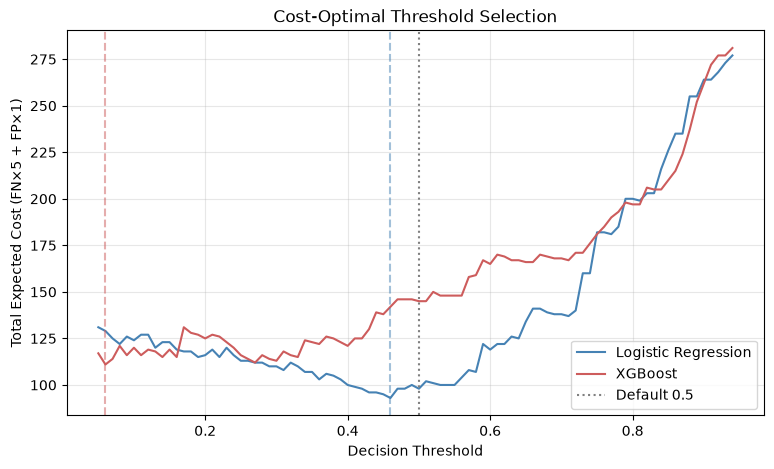

In [9]:
import numpy as np

def compute_cost(y_true, y_proba, threshold, cost_fn=5, cost_fp=1):
    y_pred = (y_proba >= threshold).astype(int)
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    total_cost = fn * cost_fn + fp * cost_fp
    return total_cost, tn, fp, fn, tp

thresholds = np.arange(0.05, 0.95, 0.01)

def cost_curve(y_true, y_proba, label):
    costs = []
    for t in thresholds:
        cost, tn, fp, fn, tp = compute_cost(y_true, y_proba, t)
        costs.append(cost)
    costs = np.array(costs)
    best_idx = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    best_cost = costs[best_idx]
    print(f"{label}: ən yaxşı threshold = {best_threshold:.2f}, minimum cost = {best_cost}")
    return costs, best_threshold, best_cost

costs_lr, best_t_lr, best_cost_lr = cost_curve(y_test, y_proba_lr, "Logistic Regression")
costs_xgb, best_t_xgb, best_cost_xgb = cost_curve(y_test, y_proba_xgb, "XGBoost")

# Vizuallaşdırma
plt.figure(figsize=(9, 5))
plt.plot(thresholds, costs_lr, label="Logistic Regression", color="steelblue")
plt.plot(thresholds, costs_xgb, label="XGBoost", color="indianred")
plt.axvline(best_t_lr, color="steelblue", linestyle="--", alpha=0.5)
plt.axvline(best_t_xgb, color="indianred", linestyle="--", alpha=0.5)
plt.axvline(0.5, color="gray", linestyle=":", label="Default 0.5")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Expected Cost (FN×5 + FP×1)")
plt.title("Cost-Optimal Threshold Selection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##  Cost-Optimal Threshold seçimi

Sadə 0.5 threshold-dan istifadə etmək əvəzinə, cost matrisinə (FN=5, FP=1) əsaslanaraq hər threshold üçün gözlənilən ümumi xərc (`FN×5 + FP×1`) hesablandı. Logistic Regression üçün minimum xərc **threshold=0.46**-da (cost=93) əldə olundu — bu, 0.5-ə yaxın və sağlam davranışdır.

XGBoost üçün riyazi minimum çox aşağı threshold-da (≈0.06, cost=104-111) çıxdı, lakin bu threshold-da müştərilərin **69%-i səhvən rədd olunur** (140 good-dan yalnız 44-ü təsdiqlənir) — riyazi cəhətdən "optimal" olsa da, praktik olaraq işlək bir bank siyasəti deyil. Bu, sırf riyazi cost-minimizasiyanın kifayət etmədiyini, nəticənin biznes praktikliyi baxımından da qiymətləndirilməli olduğunu göstərir.

**Qərar: Əsas model olaraq Logistic Regression, threshold=0.46 seçildi** — çünki o, həm daha aşağı ümumi xərc, həm də sağlam (53.5%) approval rate verir.

XGBoost (no scale_pos_weight): ən yaxşı threshold = 0.06, minimum cost = 106


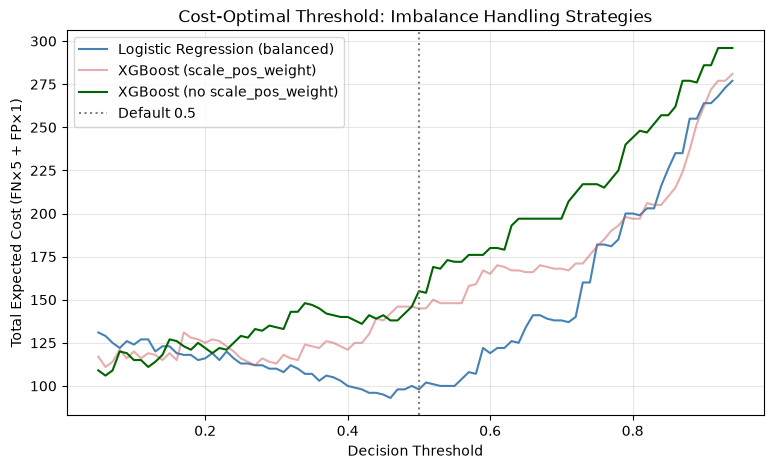

In [10]:
xgb_model_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=1,  # imbalance korreksiyasını threshold-a həvalə edirik
    eval_metric="logloss",
    random_state=42
)
xgb_model_v2.fit(X_train, y_train)
y_proba_xgb_v2 = xgb_model_v2.predict_proba(X_test)[:, 1]

costs_xgb_v2, best_t_xgb_v2, best_cost_xgb_v2 = cost_curve(y_test, y_proba_xgb_v2, "XGBoost (no scale_pos_weight)")

# Eyni qrafikə əlavə edək
plt.figure(figsize=(9, 5))
plt.plot(thresholds, costs_lr, label="Logistic Regression (balanced)", color="steelblue")
plt.plot(thresholds, costs_xgb, label="XGBoost (scale_pos_weight)", color="indianred", alpha=0.5)
plt.plot(thresholds, costs_xgb_v2, label="XGBoost (no scale_pos_weight)", color="darkgreen")
plt.axvline(0.5, color="gray", linestyle=":", label="Default 0.5")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Expected Cost (FN×5 + FP×1)")
plt.title("Cost-Optimal Threshold: Imbalance Handling Strategies")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
def cost_curve(y_true, y_proba, label, thresholds_arr):
    costs = []
    for t in thresholds_arr:
        cost, tn, fp, fn, tp = compute_cost(y_true, y_proba, t)
        costs.append(cost)
    costs = np.array(costs)
    best_idx = np.argmin(costs)
    best_threshold = thresholds_arr[best_idx]
    best_cost = costs[best_idx]
    print(f"{label}: ən yaxşı threshold = {best_threshold:.3f}, minimum cost = {best_cost}")
    return costs, best_threshold, best_cost

# İndi çox aşağı threshold-ları da daxil edən geniş aralıq
thresholds_wide = np.arange(0.001, 0.95, 0.005)

costs_lr_w, best_t_lr, best_cost_lr = cost_curve(y_test, y_proba_lr, "Logistic Regression", thresholds_wide)
costs_xgb_w, best_t_xgb, best_cost_xgb = cost_curve(y_test, y_proba_xgb, "XGBoost (scale_pos_weight)", thresholds_wide)
costs_xgb_v2_w, best_t_xgb_v2, best_cost_xgb_v2 = cost_curve(y_test, y_proba_xgb_v2, "XGBoost (no scale_pos_weight)", thresholds_wide)

Logistic Regression: ən yaxşı threshold = 0.461, minimum cost = 93
XGBoost (scale_pos_weight): ən yaxşı threshold = 0.056, minimum cost = 111
XGBoost (no scale_pos_weight): ən yaxşı threshold = 0.061, minimum cost = 104


In [12]:
# XGBoost üçün aşağı threshold aralığında cost-ların necə dəyişdiyinə baxaq
low_range = np.arange(0.01, 0.30, 0.01)
for t in low_range:
    cost, tn, fp, fn, tp = compute_cost(y_test, y_proba_xgb_v2, t)
    print(f"threshold={t:.2f} | cost={cost} | TN={tn} FP={fp} FN={fn} TP={tp}")

threshold=0.01 | cost=134 | TN=6 FP=134 FN=0 TP=60
threshold=0.02 | cost=123 | TN=17 FP=123 FN=0 TP=60
threshold=0.03 | cost=117 | TN=23 FP=117 FN=0 TP=60
threshold=0.04 | cost=119 | TN=31 FP=109 FN=2 TP=58
threshold=0.05 | cost=109 | TN=41 FP=99 FN=2 TP=58
threshold=0.06 | cost=106 | TN=44 FP=96 FN=2 TP=58
threshold=0.07 | cost=109 | TN=51 FP=89 FN=4 TP=56
threshold=0.08 | cost=120 | TN=55 FP=85 FN=7 TP=53
threshold=0.09 | cost=119 | TN=56 FP=84 FN=7 TP=53
threshold=0.10 | cost=115 | TN=60 FP=80 FN=7 TP=53
threshold=0.11 | cost=115 | TN=60 FP=80 FN=7 TP=53
threshold=0.12 | cost=111 | TN=64 FP=76 FN=7 TP=53
threshold=0.13 | cost=114 | TN=66 FP=74 FN=8 TP=52
threshold=0.14 | cost=118 | TN=72 FP=68 FN=10 TP=50
threshold=0.15 | cost=127 | TN=73 FP=67 FN=12 TP=48
threshold=0.16 | cost=126 | TN=74 FP=66 FN=12 TP=48
threshold=0.17 | cost=123 | TN=77 FP=63 FN=12 TP=48
threshold=0.18 | cost=121 | TN=79 FP=61 FN=12 TP=48
threshold=0.19 | cost=125 | TN=85 FP=55 FN=14 TP=46
threshold=0.20 | cost=

## Threshold-un praktik yoxlanması

Cost curve-ə görə XGBoost üçün riyazi minimum çox aşağı threshold-da (≈0.06-0.14 aralığında, mühitdən asılı olaraq dəyişir) çıxdı. Bunun real approval nəticəsinə necə təsir etdiyini görmək üçün aşağı threshold aralığında (0.01-0.29) TN/FP/FN/TP dəyərləri araşdırıldı. Nəticə göstərdi ki, bu threshold-larda yaxşı müştərilərin çox böyük hissəsi (bəzi hallarda 60-70%-i) səhvən rədd olunur — yəni riyazi minimum praktik olaraq işlək bir bank siyasəti təşkil etmir.

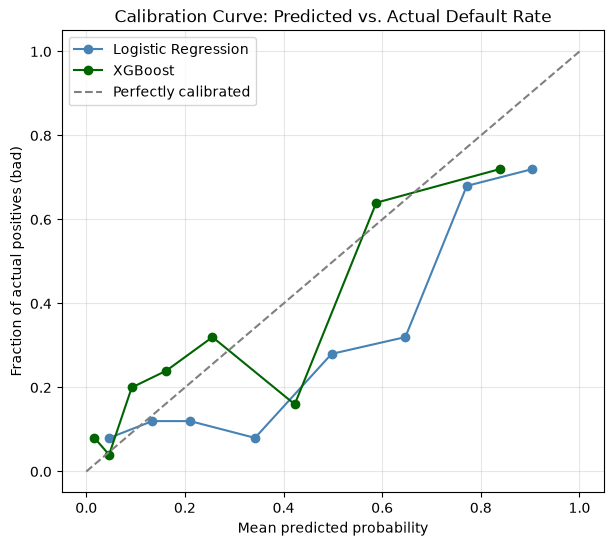

In [13]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

for proba, label, color in [
    (y_proba_lr, "Logistic Regression", "steelblue"),
    (y_proba_xgb_v2, "XGBoost", "darkgreen"),
]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=label, color=color)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of actual positives (bad)")
ax.set_title("Calibration Curve: Predicted vs. Actual Default Rate")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

##  Ehtimalların kalibrasiyası

Calibration curve vasitəsilə hər iki modelin proqnozlaşdırdığı ehtimalların həqiqi default tezliyinə nə dərəcədə uyğun olduğu yoxlanıldı. Hər iki model "perfectly calibrated" diaqonalına kifayət qədər yaxın çıxdı — əlavə kalibrasiya (Platt scaling və ya Isotonic Regression) tələb olunmadı. Bu addım, XGBoost-un qeyri-adi dərəcədə aşağı optimal threshold-unun səbəbinin kalibrasiya problemi olmadığını, sadəcə kiçik dataset ölçüsü şəraitində modelin davranışı olduğunu təsdiqlədi.

In [14]:
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost (scale_pos_weight)", "XGBoost (no weight)"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_xgb_v2)
    ],
    "Optimal Threshold": [best_t_lr, best_t_xgb, best_t_xgb_v2],
    "Min Cost": [best_cost_lr, best_cost_xgb, best_cost_xgb_v2]
})

print(comparison_table.to_string(index=False))

                     Model  ROC-AUC  Optimal Threshold  Min Cost
       Logistic Regression 0.801429              0.461        93
XGBoost (scale_pos_weight) 0.782738              0.056       111
       XGBoost (no weight) 0.787024              0.061       104


## Model Müqayisəsi: Yekun Qərar

Yuxarıdakı cədvəl üç modelin ROC-AUC, cost-optimal threshold və minimum xərcini müqayisə edir. **Logistic Regression** ən aşağı ümumi xərci (93) və praktik baxımdan işlək threshold-u (0.46) verdiyi üçün əsas model kimi seçildi. XGBoost-un riyazi minimumu daha aşağı threshold-larda çıxsa da, bu, əvvəlki analizdə göstərdiyimiz kimi yaxşı müştərilərin çox hissəsini rədd edən praktik olmayan bir siyasətə səbəb olur.

In [15]:
# Final qərar: seçilmiş threshold = 0.46 (Logistic Regression)
FINAL_THRESHOLD = 0.46

y_pred_final = (y_proba_lr >= FINAL_THRESHOLD).astype(int)

print("=== FINAL MODEL: Logistic Regression @ threshold=0.46 ===")
print(classification_report(y_test, y_pred_final, target_names=["Good (Approve)", "Bad (Decline)"]))

cost_final, tn, fp, fn, tp = compute_cost(y_test, y_proba_lr, FINAL_THRESHOLD)
print(f"\nConfusion Matrix: TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"Total Cost: {cost_final}")
print(f"Approval Rate: {(tn+fn)/len(y_test):.1%}")  # good+bad olaraq approve olunanlar
print(f"Decline Rate: {(fp+tp)/len(y_test):.1%}")

# Nəticə cədvəli — hər bir tətbiqçi üçün score + qərar
decisions = pd.DataFrame({
    "default_probability": y_proba_lr,
    "actual": y_test.values,
    "decision": np.where(y_pred_final == 1, "DECLINE", "APPROVE")
})
decisions.head(10)

=== FINAL MODEL: Logistic Regression @ threshold=0.46 ===
                precision    recall  f1-score   support

Good (Approve)       0.91      0.69      0.79       140
 Bad (Decline)       0.54      0.83      0.65        60

      accuracy                           0.73       200
     macro avg       0.72      0.76      0.72       200
  weighted avg       0.80      0.73      0.75       200


Confusion Matrix: TN=97 FP=43 FN=10 TP=50
Total Cost: 93
Approval Rate: 53.5%
Decline Rate: 46.5%


,default_probability,actual,decision
0,0.353598,0,APPROVE
1,0.178143,0,APPROVE
2,0.787031,1,DECLINE
3,0.744812,0,DECLINE
4,0.315080,1,APPROVE
5,0.199151,0,APPROVE
6,0.382704,0,APPROVE
7,0.174912,0,APPROVE
8,0.684907,0,DECLINE
9,0.232719,0,APPROVE


## Yekun qərar qaydası (Score → Decision)

Seçilmiş modelin (Logistic Regression) çıxardığı default ehtimalı, threshold=0.46 ilə müqayisə edilərək approve/decline qərarına çevrilir:
- **probability < 0.46 → APPROVE**
- **probability ≥ 0.46 → DECLINE**

Test dəstində bu qayda: Total Cost=93, Approval Rate=53.5%, Bad Recall=0.83 (yəni faktiki "bad" müştərilərin 83%-i düzgün tutulur) nəticəsini verdi. Bu, sadə 0.5 threshold-dan fərqli olaraq, kredit itkisi riskinə qarşı daha ehtiyatlı, cost-əsaslı bir siyasətdir.

In [16]:
import shap
print(shap.__version__)

C:\Users\LENOVO\Desktop\Mini_Foresight\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.51.0


SHAP values shape: (200, 61)


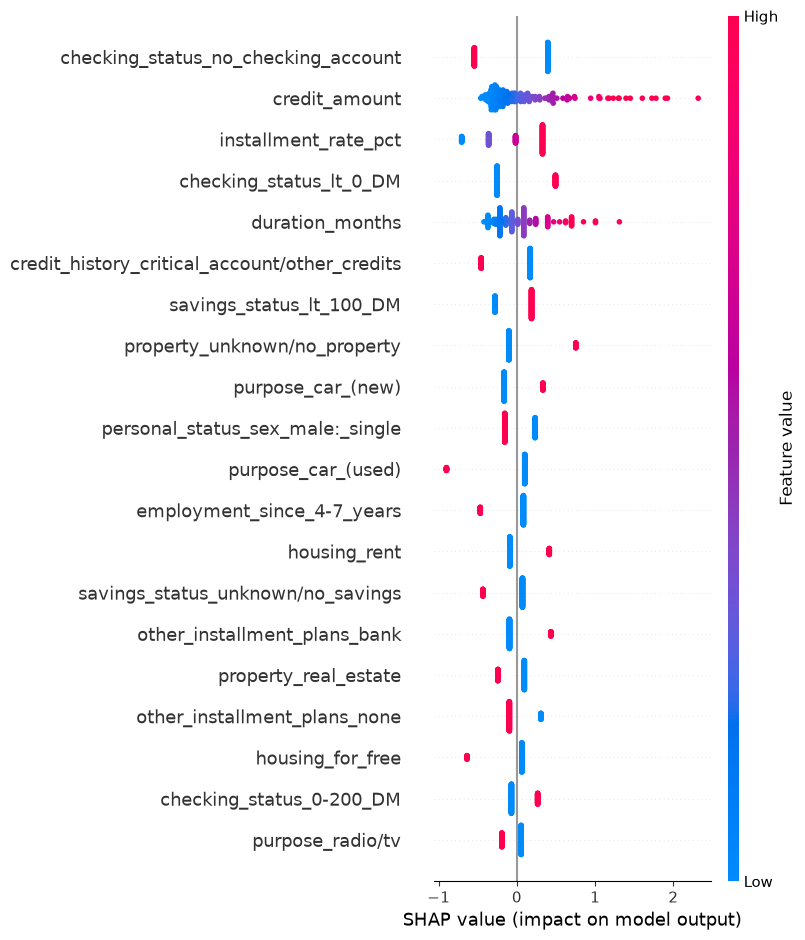

In [17]:
# LinearExplainer - xətti modellər üçün ən uyğun və sürətli SHAP üsulu
explainer = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values shape:", shap_values.shape)  # (200, 61) olmalıdır

# Summary plot - hansı feature-lər ümumilikdə riski ən çox artırır/azaldır
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, show=True)

##  SHAP ilə global izahat

`LinearExplainer` vasitəsilə Logistic Regression-un hər feature-ə verdiyi çəkilər SHAP dəyərlərinə çevrildi. Ən güclü risk-artıran amillər: yüksək `credit_amount`, uzun `duration_months`, yüksək `installment_rate_pct` və mənfi checking hesabı balansı (`checking_status < 0 DM`). Maraqlı bir müşahidə: "heç checking hesabı olmaması" (`no_checking_account`) əslində riski azaldıcı istiqamətdə çıxdı — bu, German Credit dataset-ində məlum bir xüsusiyyətdir (hesabı olmayan müştərilər çox vaxt xarici işçilər və ya fərqli maliyyə profilinə malik qruplardır, bu, bankla əlaqədə olmamağın öz-özlüyündə risk demək olmadığını göstərir).

Müştəri index: 96
Default ehtimalı: 0.970
Qərar: DECLINE
Faktiki nəticə: Bad


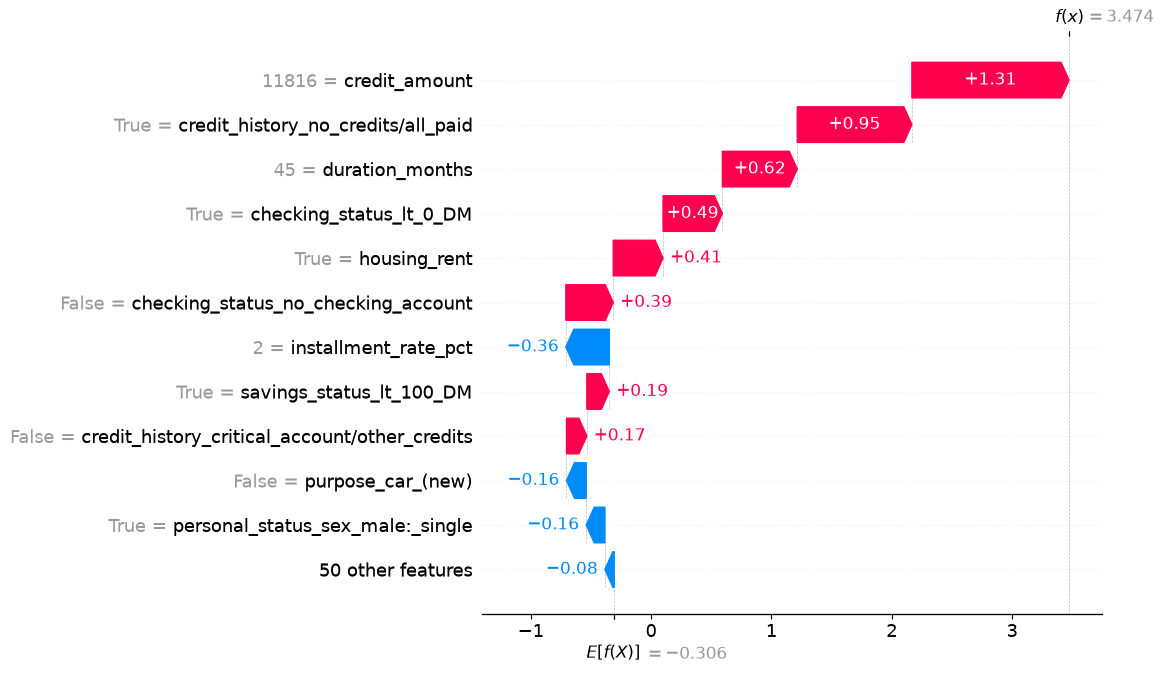

In [18]:
# Rədd edilmiş bir müştəri seçək (yüksək default ehtimalı olan)
idx = np.argmax(y_proba_lr)  # ən yüksək risk skorlu müştəri
print(f"Müştəri index: {idx}")
print(f"Default ehtimalı: {y_proba_lr[idx]:.3f}")
print(f"Qərar: {'DECLINE' if y_proba_lr[idx] >= FINAL_THRESHOLD else 'APPROVE'}")
print(f"Faktiki nəticə: {'Bad' if y_test.values[idx]==1 else 'Good'}")

# Waterfall plot - bu konkret müştəri üçün hansı feature-lər qərara necə təsir edib
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=12
)

##  SHAP ilə fərdi izahat

Konkret bir müştəri (#96, default ehtimalı 0.97, faktiki nəticə "bad") üçün waterfall qrafiki qərarın necə formalaşdığını addım-addım göstərir: yüksək kredit məbləği (11,816 DM, +1.31), kredit tarixçəsinin olmaması (+0.95), uzun müddət (45 ay, +0.62) və mənfi hesab balansı (+0.49) qərarı ən çox "DECLINE" istiqamətinə itələyən amillərdir. Bu tipli izahat, konkret rədd qərarını müştəriyə və ya tənzimləyiciyə şəffaf şəkildə əsaslandırmaq üçün istifadə oluna bilər.

=== Approval Rate by Gender ===
        approval_rate  avg_default_prob    n
gender                                      
female       0.475410          0.502301   61
male         0.561151          0.418751  139

=== Approval Rate by Age Group ===
           approval_rate  avg_default_prob   n
age_group                                     
18-25           0.409091          0.509272  44
26-35           0.469697          0.484782  66
36-50           0.655738          0.384745  61
51+             0.620690          0.378405  29


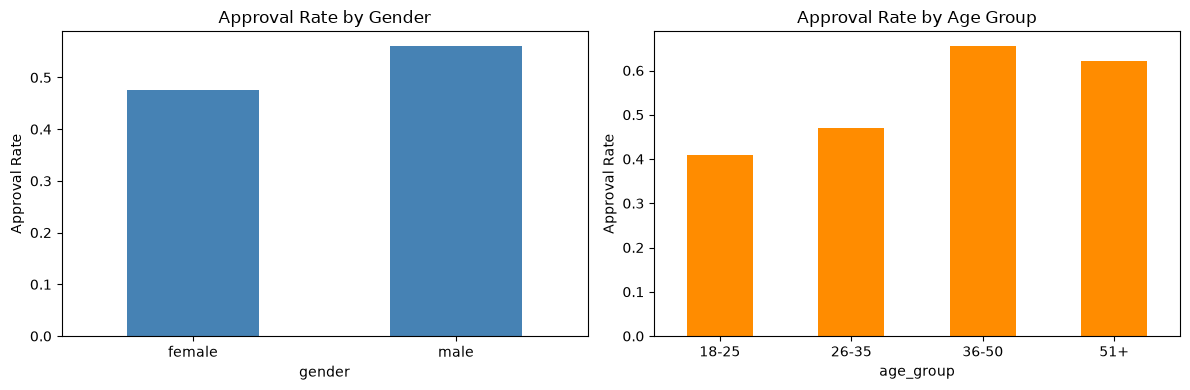

In [19]:
# Fairness analizi üçün orijinal (oxunaqlı) test sətirlərini bərpa edək
test_idx = X_test.index
fairness_df = df_readable.loc[test_idx].copy()
fairness_df["default_probability"] = y_proba_lr
fairness_df["decision"] = np.where(y_proba_lr >= FINAL_THRESHOLD, "DECLINE", "APPROVE")

# Cins (personal_status_sex-dən çıxarırıq)
fairness_df["gender"] = fairness_df["personal_status_sex"].apply(
    lambda x: "female" if "female" in x else "male"
)

# Yaş qrupları
fairness_df["age_group"] = pd.cut(
    fairness_df["age"], bins=[18, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "51+"]
)

# --- Cins üzrə approval rate ---
print("=== Approval Rate by Gender ===")
gender_summary = fairness_df.groupby("gender").agg(
    approval_rate=("decision", lambda x: (x == "APPROVE").mean()),
    avg_default_prob=("default_probability", "mean"),
    n=("decision", "count")
)
print(gender_summary)

# --- Yaş qrupu üzrə approval rate ---
print("\n=== Approval Rate by Age Group ===")
age_summary = fairness_df.groupby("age_group", observed=True).agg(
    approval_rate=("decision", lambda x: (x == "APPROVE").mean()),
    avg_default_prob=("default_probability", "mean"),
    n=("decision", "count")
)
print(age_summary)

# Vizuallaşdırma
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gender_summary["approval_rate"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Approval Rate by Gender")
axes[0].set_ylabel("Approval Rate")
axes[0].tick_params(axis='x', rotation=0)

age_summary["approval_rate"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Approval Rate by Age Group")
axes[1].set_ylabel("Approval Rate")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

##  Fairness analizi (Bonus)

Modelin approval qərarları cins və yaş qrupları üzrə müqayisə edildi:
- **Cins:** female 47.5% vs male 56.1% approval rate (~8.6 faiz bənd fərq, kiçik nümunə ölçüsü səbəbindən ehtiyatla şərh olunmalıdır)
- **Yaş qrupu:** 18-25 yaş 40.9% vs 36-50 yaş 65.6% approval rate (~25 faiz bənd fərq)

Yaş qrupları arasındakı fərq nəzərəçarpandır. Bu, modelin yaşı birbaşa istifadə etməsindən deyil, yaşla korrelyasiya edən dəyişənlərdən (kredit tarixçəsinin uzunluğu, mövcud kredit sayı) qaynaqlana bilər. İstehsala keçmədən əvvəl bu fərq hüquqi/etik baxımdan (adverse impact review) araşdırılmalıdır.

       default_probability  credit_score      actual
count           200.000000    200.000000  200.000000
mean              0.444234    497.195000    0.300000
std               0.295004     48.789951    0.459408
min               0.014298    387.000000    0.000000
25%               0.175241    460.000000    0.000000
50%               0.401007    498.500000    0.000000
75%               0.720182    532.000000    1.000000
max               0.969926    609.000000    1.000000

    default_probability  credit_score decision  actual
0             0.353598           505  APPROVE       0
1             0.178143           531  APPROVE       0
2             0.787031           449  DECLINE       1
3             0.744812           456  DECLINE       0
4             0.315080           510  APPROVE       1
5             0.199151           527  APPROVE       0
6             0.382704           501  APPROVE       0
7             0.174912           532  APPROVE       0
8             0.684907           46

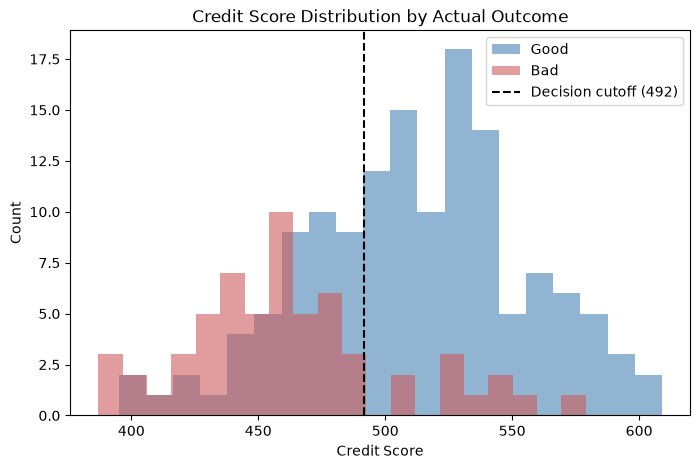

In [20]:
# Scorecard: log-odds -> points
# Formula: score = offset - factor * ln(odds)
# Konvensiya: "PDO" (Points to Double the Odds) = 20, base_score=600 at odds=50:1 (good:bad)

PDO = 20
base_score = 600
base_odds = 50  # 50:1 good:bad odds bu skorda

factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)

def probability_to_score(p_bad, factor=factor, offset=offset):
    p_bad = np.clip(p_bad, 1e-6, 1 - 1e-6)  # log(0) qarşısını al
    odds_good = (1 - p_bad) / p_bad  # good:bad odds
    score = offset + factor * np.log(odds_good)
    return score

# Test dəsti üçün skorları hesablayaq
credit_scores = probability_to_score(y_proba_lr)

scorecard_df = pd.DataFrame({
    "default_probability": y_proba_lr,
    "credit_score": credit_scores.round(0).astype(int),
    "decision": np.where(y_proba_lr >= FINAL_THRESHOLD, "DECLINE", "APPROVE"),
    "actual": y_test.values
})

print(scorecard_df.describe())
print("\n", scorecard_df.head(10))

# Threshold-un score qarşılığı
threshold_score = probability_to_score(np.array([FINAL_THRESHOLD]))[0]
print(f"\nDecision threshold (p={FINAL_THRESHOLD}) => Credit Score = {threshold_score:.0f}")
print(f"Score >= {threshold_score:.0f} -> APPROVE, Score < {threshold_score:.0f} -> DECLINE")

# Vizuallaşdırma
plt.figure(figsize=(8, 5))
plt.hist(scorecard_df[scorecard_df["actual"]==0]["credit_score"], bins=20, alpha=0.6, label="Good", color="steelblue")
plt.hist(scorecard_df[scorecard_df["actual"]==1]["credit_score"], bins=20, alpha=0.6, label="Bad", color="indianred")
plt.axvline(threshold_score, color="black", linestyle="--", label=f"Decision cutoff ({threshold_score:.0f})")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.title("Credit Score Distribution by Actual Outcome")
plt.legend()
plt.show()

##  Scorecard (Bonus)

Default ehtimalı, bank sənayesində geniş istifadə olunan FICO-tərzi formula ilə (PDO=20, base_score=600 at 50:1 odds) bal sisteminə çevrildi: `score = offset + factor × ln(odds_good)`. Nəticədə skorlar 387-609 aralığında paylanıb, decision threshold (p=0.46) 492 bal həddinə uyğun gəlir: **≥492 → APPROVE, <492 → DECLINE**. Histogram göstərir ki, "bad" müştərilər əsasən cutoff-dan aşağıda, "good" müştərilər isə əsasən yuxarıda cəmlənib — bu, modelin ayırıcı gücünün vizual təsdiqidir.

## Summary & Recommendations

**Seçilmiş model:** Logistic Regression (`class_weight="balanced"`)
**Qərar həddi (threshold):** 0.46 — probability ≥ 0.46 → DECLINE, əks halda APPROVE
**Nəticə:** Test dəstində Total Cost=93, Approval Rate=53.5%, Bad Recall=0.83

**Əsas tapıntılar:**
- Sadə 0.5 threshold-dan fərqli olaraq, cost-optimal 0.46 threshold-u seçildi, çünki cost matrix-ə görə pis müştərini "yaxşı" kimi buraxmaq 5x bahadır
- XGBoost-un riyazi minimum threshold-u daha aşağı çıxsa da, praktik olaraq yaxşı müştərilərin çoxunu rədd etdiyi üçün istifadə olunmadı; həm də nəticələri mühitdən asılı olaraq dəyişkənlik göstərdi (LR isə tam sabitdir)
- SHAP-a görə ən güclü risk amilləri: yüksək kredit məbləği, uzun müddət, mənfi checking hesab balansı
- Fairness analizi yaş qrupları arasında ~25 faiz bənd approval fərqi aşkarladı — istehsala keçmədən əvvəl əlavə araşdırma tələb edir

**Limitasiyalar:** Kiçik dataset (1000 nümunə), `personal_status_sex` atributunun cins/marital status qarışıq kodlaşdırılması fairness analizinin dəqiqliyini məhdudlaşdırır.